# Lecture 4 — What does `fit()` actually do?

**Companion notebook for Frankfurt UAS · Machine Learning · Lecture 4 of 9**

Two model families on two simple datasets:

1. **Linear Regression on AAPL** — predict tomorrow's price from today's price.
   *One feature, one line, two numbers.* The simplest possible parametric model.
2. **KNN on Iris** — classify flowers from petal measurements.
   *The dataset you used in the lab.* Now you'll see what `fit()` actually did there.

For each: the same question — *what does `fit()` actually do?*

The answers will be very different.

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.datasets import load_iris

# Cosmetic
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

print("All imports OK.")

All imports OK.


---

## Section 1 — Load both datasets

We need:
- **AAPL** for Linear Regression (one feature: today's Close)
- **Iris** for KNN classification (built into sklearn — always works offline)

In [4]:
# --- AAPL: try real data, fall back to synthetic ---
def load_real_aapl():
    import yfinance as yf
    df = yf.download("AAPL", start="2022-01-01", end="2024-12-31",
                     progress=False, auto_adjust=True)
    if df.empty:
        raise RuntimeError("yfinance returned no data")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df[["Close"]].copy()

def make_synthetic_aapl():
    n = 750
    dates = pd.bdate_range("2022-01-03", periods=n)
    returns = np.random.randn(n) * 0.015 + 0.0004
    price = 150 * np.exp(np.cumsum(returns))
    return pd.DataFrame({"Close": price}, index=dates)

try:
    aapl = load_real_aapl()
    print(f"AAPL: live data ({len(aapl)} days)")
except Exception:
    aapl = make_synthetic_aapl()
    print(f"AAPL: synthetic data ({len(aapl)} days) — yfinance unavailable")

# Build the simplest possible setup: today's Close → tomorrow's Close
aapl["target"] = aapl["Close"].shift(-1)
aapl = aapl.dropna()
print(aapl.head())

AAPL: live data (752 days)
Price            Close      target
Date                              
2022-01-03  178.103668  175.843262
2022-01-04  175.843262  171.165848
2022-01-05  171.165848  168.308456
2022-01-06  168.308456  168.474869
2022-01-07  168.474869  168.494415


In [5]:
# --- Iris: built into sklearn, no internet needed ---
iris = load_iris()
print(f"Iris: {iris.data.shape[0]} flowers, {iris.data.shape[1]} features")
print(f"Features: {iris.feature_names}")
print(f"Classes:  {list(iris.target_names)}")
print()

# We'll use 2 features so we can plot the decision boundary.
# Petal length & width separate the species really cleanly.
X_iris = iris.data[:, [2, 3]]   # petal length, petal width
y_iris = iris.target
feature_names = ["petal length (cm)", "petal width (cm)"]
class_names = list(iris.target_names)

print(f"Using features: {feature_names}")

Iris: 150 flowers, 4 features
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:  [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Using features: ['petal length (cm)', 'petal width (cm)']


---

## Section 2 — Look at the data first

Both tasks have the same conceptual structure: **points in a space, with values to predict**.
The difference: AAPL has a numeric value (regression), Iris has a class label (classification).

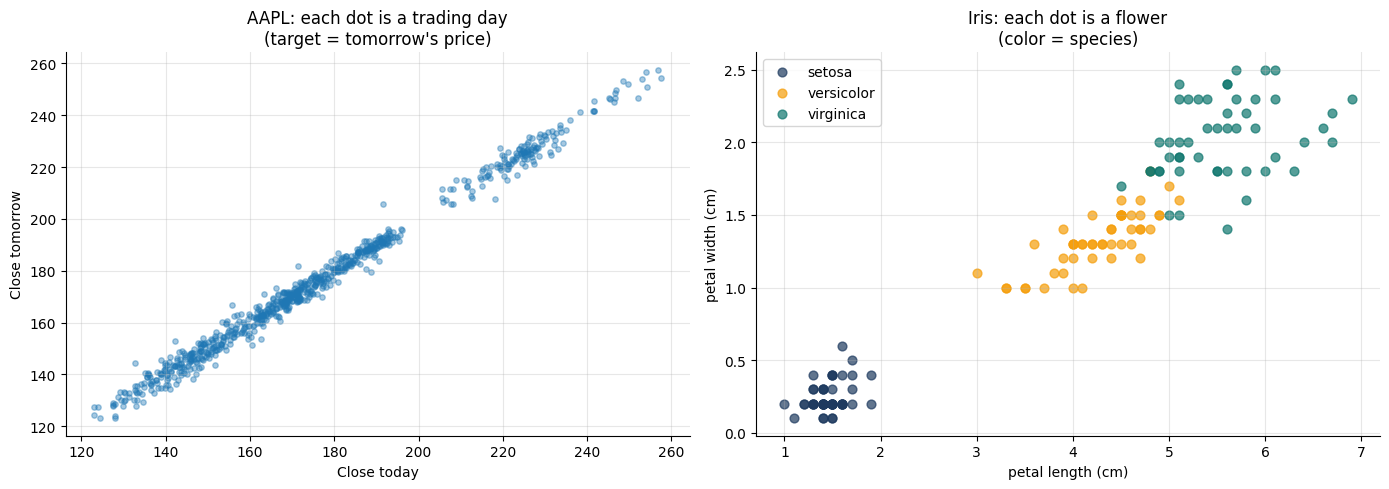

In [6]:
# AAPL: simple 2D scatter — today's close vs tomorrow's close
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(aapl["Close"], aapl["target"], alpha=0.4, s=15)
ax.set_xlabel("Close today")
ax.set_ylabel("Close tomorrow")
ax.set_title("AAPL: each dot is a trading day\n(target = tomorrow's price)")
ax.grid(True, alpha=0.3)

# Iris: 2D scatter, colored by species
ax = axes[1]
colors = ["#1E3A5F", "#F59E0B", "#0F766E"]
for cls, color, name in zip(range(3), colors, class_names):
    mask = (y_iris == cls)
    ax.scatter(X_iris[mask, 0], X_iris[mask, 1], c=color, label=name, s=40, alpha=0.7)
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_title("Iris: each dot is a flower\n(color = species)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Notice the structure in both:**

- **AAPL:** the points line up roughly along a diagonal. Higher Close today → higher Close tomorrow. There's a *line* hiding in there waiting to be found.
- **Iris:** the three species form distinct clusters in petal-space. Setosa (left) is far apart, versicolor and virginica overlap a bit. There are *regions* waiting to be drawn.

These are two different kinds of structure — and they call for two different kinds of model.

---

## Section 3 — Family 1: Linear Regression

The simplest possible model:

$$\hat{y} = w \cdot x + b$$

**Two numbers**, $w$ (slope) and $b$ (intercept). That's the entire model.
`fit()` will find good values for these two numbers.

In [7]:
# Time-series split — never random for stock data
X = aapl[["Close"]]   # just ONE feature
y = aapl["target"]

tscv = TimeSeriesSplit(n_splits=5)
train_idx, test_idx = list(tscv.split(X))[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)} days   Test: {len(X_test)} days")

Train: 626 days   Test: 125 days


In [8]:
X_train.head(100)

Price,Close
Date,
2022-01-03,178.103668
2022-01-04,175.843262
2022-01-05,171.165848
2022-01-06,168.308456
2022-01-07,168.474869
...,...
2022-05-19,134.771103
2022-05-20,135.006607
2022-05-23,140.422989


**Now fit. What's `fit()` about to do?** Find two numbers.

In [9]:
y_train.head(100)


Date
2022-01-03    175.843262
2022-01-04    171.165848
2022-01-05    168.308456
2022-01-06    168.474869
2022-01-07    168.494415
                 ...    
2022-05-19    135.006607
2022-05-20    140.422989
2022-05-23    137.724609
2022-05-24    137.881622
2022-05-25    141.080399
Name: target, Length: 100, dtype: float64

In [10]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

w = model_lr.coef_[0]
b = model_lr.intercept_

print(f"Slope     w = {w:.4f}")
print(f"Intercept b = {b:.4f}")
print()
print(f"Model:  ŷ = {w:.4f} · Close + {b:.4f}")
print()
print(">>> Two numbers ARE the trained model.")
print(">>> Save these two numbers, throw the data away — you can still predict.")

Slope     w = 0.9949
Intercept b = 0.9158

Model:  ŷ = 0.9949 · Close + 0.9158

>>> Two numbers ARE the trained model.
>>> Save these two numbers, throw the data away — you can still predict.


**Now draw the line.** This is what `fit()` produced — visually:

/Users/bertram/Projects/github.com/b3rtram/uas_ml/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


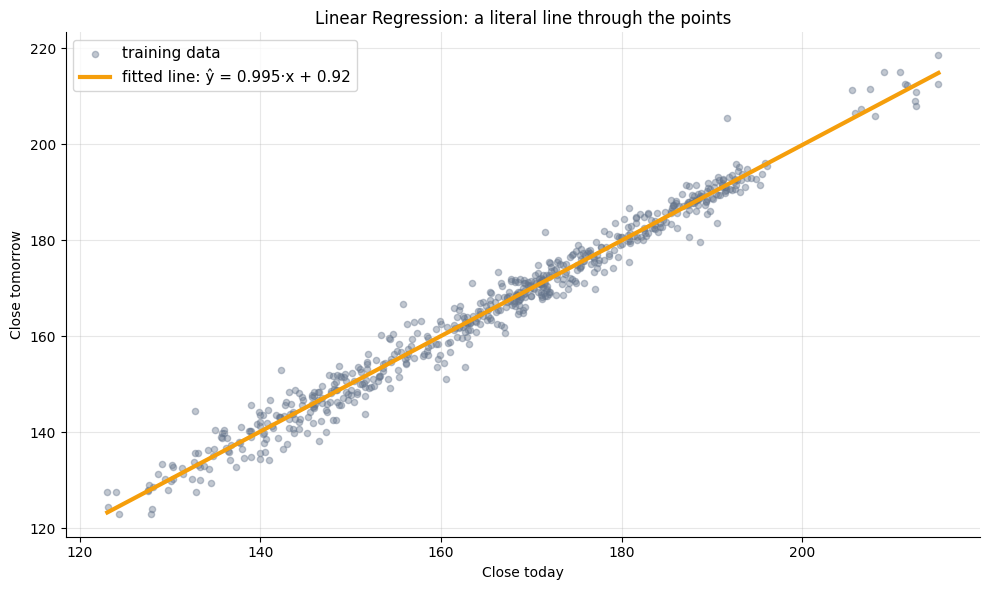

In [11]:
# Plot the line through the points
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter of training data
ax.scatter(X_train, y_train, alpha=0.4, s=20, label="training data", color="#64748B")

# Draw the fitted line
x_line = np.linspace(X_train.min().values[0], X_train.max().values[0], 100).reshape(-1, 1)
y_line = model_lr.predict(x_line)
ax.plot(x_line, y_line, color="#F59E0B", linewidth=3,
        label=f"fitted line: ŷ = {w:.3f}·x + {b:.2f}")

ax.set_xlabel("Close today")
ax.set_ylabel("Close tomorrow")
ax.set_title("Linear Regression: a literal line through the points")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

That orange line *is* the model. Every point on it is a prediction. Two numbers define the entire line.

Now check how it does on the test set (days the model has never seen):

In [12]:
X_test.head(100)

Price,Close
Date,
2024-07-02,218.579498
2024-07-03,219.849655
2024-07-05,224.602921
2024-07-08,226.071564
2024-07-09,226.924942
...,...
2024-11-14,226.980072
2024-11-15,223.777573
2024-11-18,226.781174


Test MSE:  8.6121
Test RMSE: 2.9346  (in price units)


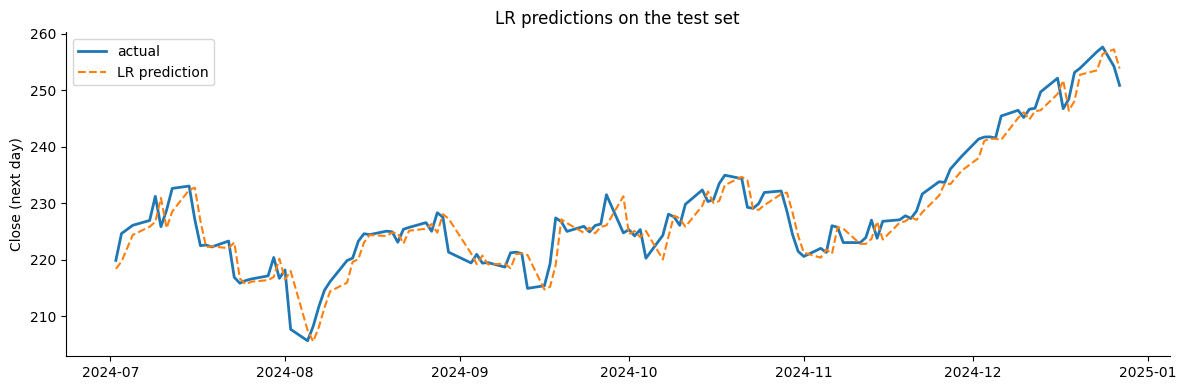

In [13]:
y_pred_lr = model_lr.predict(X_test)
mse_lr = np.mean((y_test - y_pred_lr)**2)
rmse_lr = np.sqrt(mse_lr)
print(f"Test MSE:  {mse_lr:.4f}")
print(f"Test RMSE: {rmse_lr:.4f}  (in price units)")

# Plot test predictions over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test.index, y_test.values, label="actual", linewidth=2)
ax.plot(y_test.index, y_pred_lr, label="LR prediction", linestyle="--")
ax.set_title("LR predictions on the test set")
ax.set_ylabel("Close (next day)")
ax.legend()
plt.tight_layout()
plt.show()

> **Quick check:** What did `fit()` change in this LR model?
> *(Answer: the two numbers w and b. Nothing else.)*

---

## Section 4 — Family 2: KNN on Iris

Iris is the classical KNN demo — and it's the dataset you worked with in the lab.

The task: given a flower's petal length and width, classify it as
*setosa*, *versicolor*, or *virginica*.

KNN's strategy: find the k nearest stored flowers, take a majority vote.

### First: split, then scale

KNN uses Euclidean distance. Iris features are already in similar units (cm),
but it's good practice to scale anyway — and you definitely need it for datasets
where features have wildly different scales.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)
print(f"Train: {len(X_train)} flowers   Test: {len(X_test)} flowers")

# Scale (best practice for any distance-based method)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Features scaled to mean 0, std 1.")

Train: 105 flowers   Test: 45 flowers
Features scaled to mean 0, std 1.


**Now fit KNN. What's `fit()` about to do this time?**

In [15]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_s, y_train)
print("Fit complete.")

Fit complete.


**There's no `coef_`. Let's prove it.**

In [16]:
try:
    print(model_knn.coef_)
except AttributeError as e:
    print(f"AttributeError: {e}")
    print()
    print(">>> KNN has no coefficients. There are no parameters to learn.")
    print(">>> Compare with LR above, where two numbers WERE the model.")

AttributeError: 'KNeighborsClassifier' object has no attribute 'coef_'

>>> KNN has no coefficients. There are no parameters to learn.
>>> Compare with LR above, where two numbers WERE the model.


In [17]:
# What KNN.fit() actually did was: store the data.
print(f"Stored training data shape: {model_knn._fit_X.shape}")
print(f"Stored training labels:     {model_knn._y.shape}")
print()
print(">>> The 'model' for KNN is just the training data + a reference to it.")
print(">>> fit() saved that reference. That's the whole 'training'.")

Stored training data shape: (105, 2)
Stored training labels:     (105,)

>>> The 'model' for KNN is just the training data + a reference to it.
>>> fit() saved that reference. That's the whole 'training'.


### Visualize what KNN does — the decision boundary

This is the magic of KNN visualized: at every point in the feature space,
KNN asks "what would my k nearest neighbors say?" The colors below show those answers.

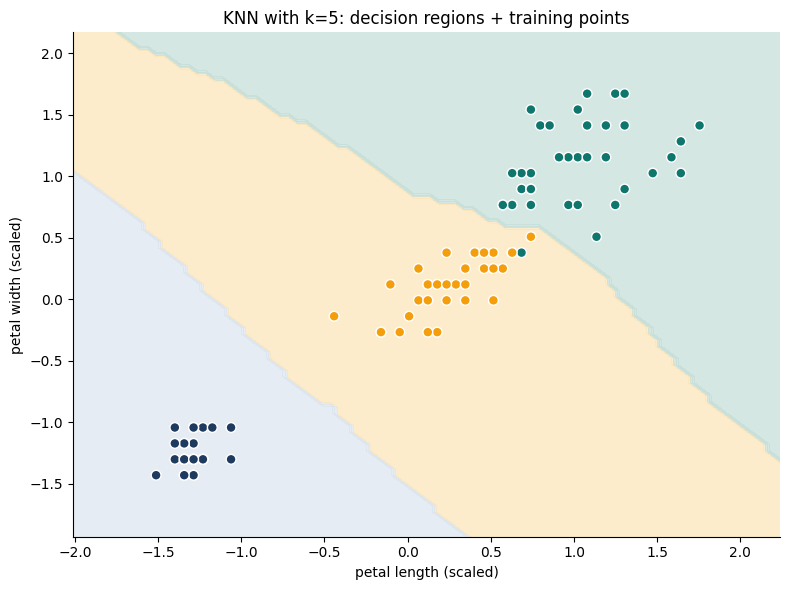

In [18]:
def plot_decision_boundary(model, X_scaled, y, scaler, ax, title):
    """Plot the decision boundary of a 2D classifier."""
    h = 0.05
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    
    cmap_bg = ListedColormap(["#DBE4EE", "#FCE4B7", "#C4DDD7"])
    cmap_pts = ListedColormap(["#1E3A5F", "#F59E0B", "#0F766E"])
    
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.7)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=cmap_pts,
               edgecolor="white", s=50, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("petal length (scaled)")
    ax.set_ylabel("petal width (scaled)")

fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary(model_knn, X_train_s, y_train, scaler, ax,
                       "KNN with k=5: decision regions + training points")
plt.tight_layout()
plt.show()

Each colored region tells you what KNN would predict for any flower with those
petal measurements. The dots are the training flowers — they sit inside their own region.

Now the key experiment: **vary `k` and watch the boundary change.**

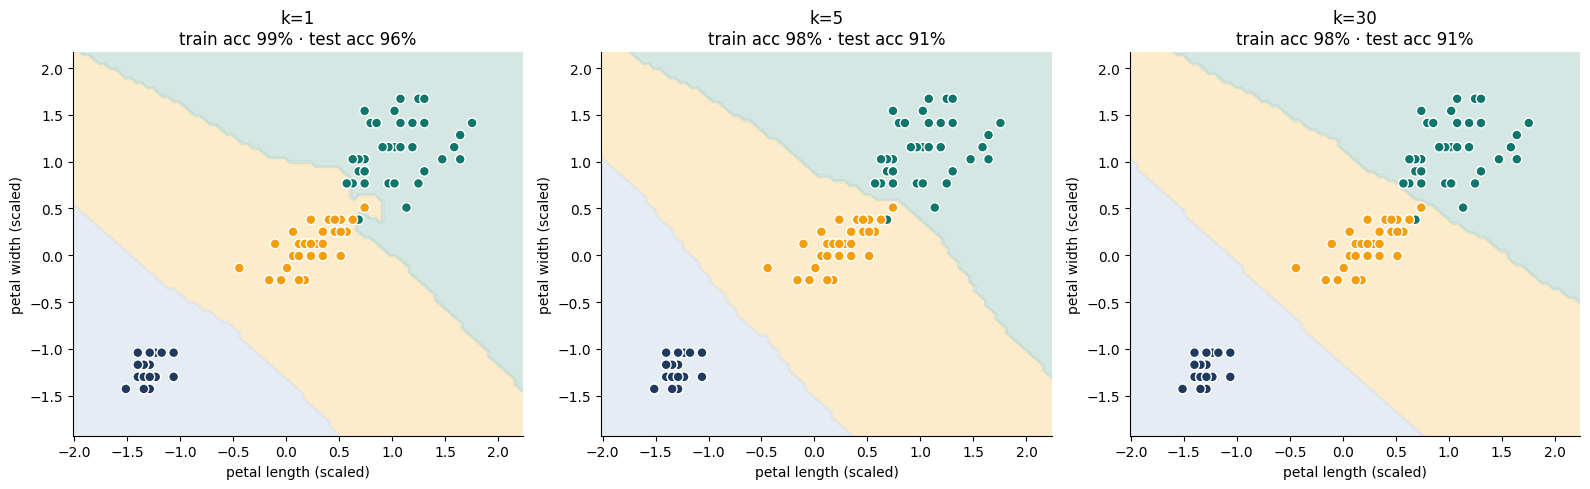

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, k in zip(axes, [1, 5, 30]):
    knn_k = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    train_acc = knn_k.score(X_train_s, y_train)
    test_acc = knn_k.score(X_test_s, y_test)
    plot_decision_boundary(knn_k, X_train_s, y_train, scaler, ax,
                           f"k={k}\ntrain acc {train_acc:.0%} · test acc {test_acc:.0%}")
plt.tight_layout()
plt.show()

Read the three boundaries:

- **k=1:** every training point owns its own little island. The boundary is jagged and follows
  individual points — even outliers. Train accuracy is **perfect** (100%) — but only because
  KNN memorized the training set. This is **overfitting**.
- **k=5:** boundaries are smoother, locally averaged over 5 neighbors. This is usually a
  good balance.
- **k=30:** boundaries are very smooth — KNN now averages over a large neighborhood,
  losing local detail. This can underfit if k is too large.

The hyperparameter `k` controls the **bias-variance tradeoff** — visually right here.

> **k is a hyperparameter** — set by us, not learned by `fit()`. Now that vocabulary word
> has a concrete meaning.

 k  train_acc  test_acc
 1   0.990476  0.955556
 3   0.980952  0.933333
 5   0.980952  0.911111
 7   0.980952  0.911111
10   0.980952  0.911111
15   0.980952  0.911111
20   0.980952  0.911111
30   0.980952  0.911111
50   0.980952  0.911111


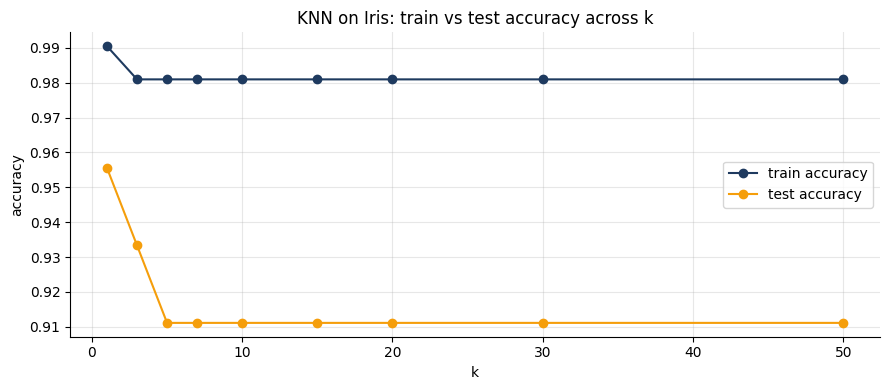

In [20]:
# Test accuracy across k
ks = [1, 3, 5, 7, 10, 15, 20, 30, 50]
results = []
for k in ks:
    knn_k = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    results.append({
        "k": k,
        "train_acc": knn_k.score(X_train_s, y_train),
        "test_acc": knn_k.score(X_test_s, y_test),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(results_df["k"], results_df["train_acc"], "o-", label="train accuracy", color="#1E3A5F")
ax.plot(results_df["k"], results_df["test_acc"], "o-", label="test accuracy", color="#F59E0B")
ax.set_xlabel("k")
ax.set_ylabel("accuracy")
ax.set_title("KNN on Iris: train vs test accuracy across k")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Notice how train accuracy starts perfect at k=1 (the model memorizes everything)
and decreases as k grows. Test accuracy peaks somewhere in the middle — that's the
sweet spot. We'll formalize this as the **bias-variance tradeoff** in V6.

---

## Section 5 — Two stories of `fit()`

We have looked at `fit()` in two completely different settings:

|  | Linear Regression on AAPL | KNN on Iris |
|---|---|---|
| Task | Regression (predict a price) | Classification (predict a species) |
| What's the model? | A formula `ŷ = w·x + b` | A reference to the training data |
| What did `fit()` produce? | **Two numbers** (w, b) | **A pointer to the data** |
| Has parameters? | Yes — w and b | No |
| Has hyperparameters? | (Not in this simple version) | Yes — `k` |
| Has a loss? | Yes — MSE during fitting | No — fit doesn't optimize anything |
| Cost of training | Some computation | Almost zero (just store) |
| Cost of prediction | One multiply + add | Compute distance to all stored points |
| Knowledge lives in | The two numbers | The training data itself |

**The deeper point:**
- LR is **parametric**: knowledge lives in θ. Throw the training data away — the model still works.
- KNN is **instance-based**: knowledge lives in the data itself. Throw it away and the model is gone.

Both are legitimate ML. Both are called *supervised learning*. Different worlds.

In [21]:
# A small final demo: print the LR model in two numbers, and the KNN model
# as the size of the stored data.
print("LINEAR REGRESSION (the trained model):")
print(f"   w = {w:.4f}")
print(f"   b = {b:.4f}")
print(f"   Total: 2 numbers = {2 * 8} bytes (as float64)")
print()

knn_storage_bytes = model_knn._fit_X.nbytes + model_knn._y.nbytes
print("KNN (the trained model):")
print(f"   Stored features shape: {model_knn._fit_X.shape}")
print(f"   Stored labels shape:   {model_knn._y.shape}")
print(f"   Total: {knn_storage_bytes} bytes")
print()
print(f"KNN's model is {knn_storage_bytes // 16}× larger than LR's.")
print("And it grows linearly with training data. LR doesn't.")

LINEAR REGRESSION (the trained model):
   w = 0.9949
   b = 0.9158
   Total: 2 numbers = 16 bytes (as float64)

KNN (the trained model):
   Stored features shape: (105, 2)
   Stored labels shape:   (105,)
   Total: 2520 bytes

KNN's model is 157× larger than LR's.
And it grows linearly with training data. LR doesn't.


> **Mentimeter Poll #3 (end of lecture):** What happens when you call `model.fit(X, y)`?
>
> Compare your one-word warm-up answer with what you'd say now:
> - **For LR:** `fit()` finds two numbers that minimize MSE.
> - **For KNN:** `fit()` stores the training data. The work is deferred to predict time.

---

## Section 6 — Bonus / homework

Three small exercises to deepen the lecture content. Each is just a few lines of code.

### Exercise 1 — Add a feature to LR

Our LR used only Close. Add Volume or a moving average and refit. Did it help?

In [22]:
# Starter:
aapl["MA7"] = aapl["Close"].rolling(7).mean()
aapl_ex = aapl.dropna()

X_multi = aapl_ex[["Close", "MA7"]]
y_multi = aapl_ex["target"]

# TODO: TimeSeriesSplit, fit LinearRegression, compare MSE to the 1-feature version.
# Hint: how many numbers does fit() find now? (Inspect coef_ and intercept_.)
# Bonus: think about why MA7 might or might not help.

### Exercise 2 — KNN with k=1 — what's special?

Set k=1, fit, and check the **training** accuracy. What do you get? Why?

In [ ]:
# Starter:
knn1 = KNeighborsClassifier(n_neighbors=1).fit(X_train_s, y_train)
train_acc = knn1.score(X_train_s, y_train)
print(f"k=1 train accuracy: {train_acc:.1%}")
# TODO: explain in one sentence WHY this number is what it is.
# (Hint: what is the nearest neighbor of any training point — including itself?)

### Exercise 3 — KNN with all 4 Iris features

We used only 2 features so we could plot. Iris has 4. Refit KNN with all four
and check if test accuracy improves.

In [ ]:
# Starter:
X_iris_all = iris.data   # all 4 features
y_iris_all = iris.target

# TODO: split, scale, fit KNN with k=5, compute test accuracy.
# Compare with our 2-feature model.
# (You won't be able to plot the boundary — 4D doesn't visualize easily.)

---

## Wrap-up

By the end of this notebook you have seen — concretely, with code — that:

1. **Both models follow the universal schema** — input → model → output → compare to target.
2. **`fit()` does completely different things** for LR and KNN.
   - LR's `fit()` produced **two numbers** (w and b). Visualized as a literal line.
   - KNN's `fit()` stored the training data. There is no `coef_`, no formula.
3. **Both are valid supervised learning** — just opposite ends of a spectrum.
4. **Hyperparameters** like `k` are set by us, not learned by `fit()`.

Next lecture (V5): the **Map of ML** — where every model fits in a single landscape.